<a href="https://colab.research.google.com/github/sjlee53/ESAA-submission/blob/main/week5/1009_ESAA_YB_sklearn_02_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [3]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y, y_pred)

array([[337,  20],
       [ 30, 182]])

**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
from sklearn.metrics import accuracy_score

accuracy_score(y, y_pred)      # 0.9121

0.9121265377855887

개념 — 전체 중 맞힌 비율. (TP + TN) / 전체 = (182+337)/569

알 수 있는 점 — 91.2%로 높아 보이지만, 이 데이터는 양성 357건 : 악성 212건으로 한쪽이 1.7배 많다. 전부 "양성"이라고만 찍어도 62.7%가 나오므로 정확도만으로는 성능을 판단할 수 없다.

**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [5]:
from sklearn.metrics import precision_score

precision_score(y, y_pred)     # 0.9010

0.900990099009901

개념 — 1이라고 예측한 것 중 실제 1의 비율. TP / (TP + FP) = 182/202

알 수 있는 점 — 악성이라고 판정한 202건 중 182건이 실제 악성이다. 20건은 양성인데 악성으로 잘못 본 것(FP)이다. 환자 입장에서는 불필요한 추가 검사와 불안으로 이어진다.

**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [6]:
from sklearn.metrics import recall_score

recall_score(y, y_pred)        # 0.8585

0.8584905660377359

개념 — 실제 1 중 1이라고 맞힌 비율. TP / (TP + FN) = 182/212

알 수 있는 점 — 실제 악성 212건 중 30건을 놓쳤다(FN). 정밀도(0.901)보다 재현율(0.859)이 낮다.

암 진단에서는 이쪽이 훨씬 위험하다. 양성을 악성으로 잘못 보면 재검사로 끝나지만, 악성을 놓치면 치료 시기를 놓치기 때문이다. 이런 문제에서는 재현율을 우선해야 한다.

**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [7]:
from sklearn.metrics import f1_score

f1_score(y, y_pred)            # 0.8792

0.8792270531400966

개념 — 정밀도와 재현율의 조화평균. 2 × (정밀도 × 재현율) / (정밀도 + 재현율)

알 수 있는 점 — 0.8792로 두 값(0.901, 0.859) 사이에 있다. 조화평균이라 둘 중 하나라도 낮으면 크게 떨어진다. 한쪽만 올려서 점수를 따는 걸 막아준다. 두 지표가 비슷해서 이 모델은 한쪽에 치우치지 않았다고 볼 수 있다.

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [8]:
from sklearn.preprocessing import Binarizer


In [9]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
from sklearn.preprocessing import Binarizer

pred_proba = model_lor.predict_proba(X)

# 0으로 예측할 확률(pred_proba[:, 0])이 0.1보다 크면 0으로 분류
binarizer = Binarizer(threshold=0.1)
y_pred2 = 1 - binarizer.fit_transform(pred_proba[:, 0].reshape(-1, 1)).astype(int).flatten()

In [12]:
from sklearn.preprocessing import Binarizer

pred_proba = model_lor.predict_proba(X)

# 0으로 예측할 확률(pred_proba[:, 0])이 0.1보다 크면 0으로 분류
binarizer = Binarizer(threshold=0.1)
y_pred2 = 1 - binarizer.fit_transform(pred_proba[:, 0].reshape(-1, 1)).astype(int).flatten()

In [13]:
print(confusion_matrix(y, y_pred2))
print('정확도 %.4f' % accuracy_score(y, y_pred2))
print('정밀도 %.4f' % precision_score(y, y_pred2))
print('재현율 %.4f' % recall_score(y, y_pred2))
print('F1     %.4f' % f1_score(y, y_pred2))

[[356   1]
 [ 73 139]]
정확도 0.8699
정밀도 0.9929
재현율 0.6557
F1     0.7898


**ROC 곡선 시각화**

In [14]:
from sklearn.metrics import roc_curve


In [15]:
import matplotlib.pyplot as plt


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

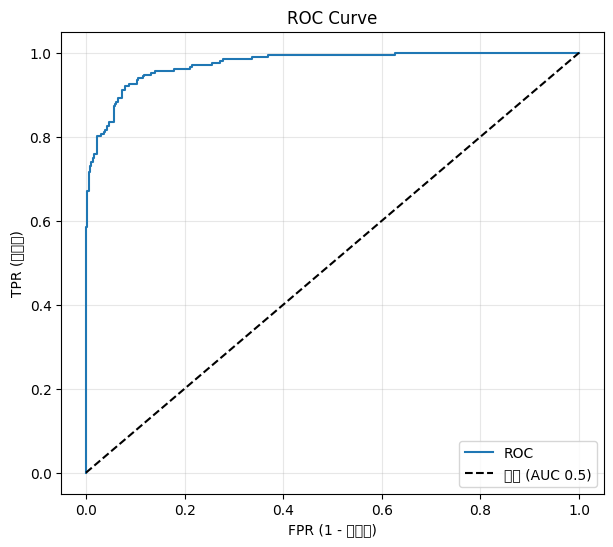

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y, pred_proba[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], 'k--', label='랜덤 (AUC 0.5)')

plt.xlabel('FPR (1 - 특이도)')
plt.ylabel('TPR (재현율)')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, pred_proba[:, 1])     # 0.9741

np.float64(0.974076423022039)

개념 — ROC 곡선 아래 면적. 임계값을 0부터 1까지 전부 바꿔가며 성능을 잰 값이라 특정 임계값에 좌우되지 않는다. 0.5면 찍는 것과 같고, 1이면 완벽하다.

알 수 있는 점 — 0.9741로 1에 가깝다. 악성 환자 한 명과 양성 환자 한 명을 무작위로 뽑았을 때, 악성 쪽에 더 높은 확률을 줄 가능성이 97.4%라는 뜻이다.

6번에서 본 것처럼 임계값에 따라 정밀도·재현율은 크게 흔들렸지만, AUC는 모델 자체의 분류 능력을 보여준다. 즉 모델은 좋고, 남은 건 임계값을 어디로 잡느냐의 문제다.